# Modelado

### 1. Introducción

**Objetivo:** Entrenar y evaluar modelos de clasificación para predecir si un cliente caerá en default en octubre, usando las features construidas en el notebook anterior.

**Métrica principal:** *Recall* — dado que el costo de no identificar a un deudor real (falso negativo) es considerablemente mayor que el costo de enviar a cobranza a un cliente que finalmente paga (falso positivo).

**Métricas secundarias:** AUC-ROC, F1-Score, Precision.

**Estrategia:**
1. Benchmark (clasificador aleatorio estratificado)
2. Modelo 1 — árbol de decisión con 2 variables
3. Modelo 2 — árbol de decisión con todas las features + pipeline
4. Modelo 3 — árbol optimizado con GridSearchCV
5. Modelo 4 — Random Forest
6. Comparativa final

In [1]:
import sys
import os
sys.path.append(os.path.abspath(os.path.join(os.getcwd(), '..')))

import warnings
warnings.filterwarnings('ignore')

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split, StratifiedKFold, cross_validate, GridSearchCV
from sklearn.dummy import DummyClassifier
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import OneHotEncoder
from sklearn.pipeline import Pipeline
from sklearn.metrics import (
    recall_score, precision_score, f1_score, roc_auc_score,
    ConfusionMatrixDisplay, RocCurveDisplay
)

import src.data.preprocess as pp
import src.features.feature_engineering as fe

---
### 2. Carga y preparación del dataset

In [2]:
df_raw = pp.preprocesar_datos()
df = fe.aplicar_feature_engineering(df_raw)

print(f'Shape: {df.shape}')
df.head()

Iniciando preprocesamiento...
Registros iniciales: 30000
Registros eliminados por inconsistencias de deuda: 1739
Registros eliminados por inconsistencias factura-pago: 2769
Registros finales: 25492
Preprocesamiento completado.
Shape: (25492, 15)


,limite_credito,genero,educacion,estado_civil,edad,pago_sep,factura_sep,default_oct,tiene_deuda_sep,n_meses_deuda_sep,sin_uso_sep,pago_minimo_sep,pago_completo_sep,ratio_uso_sep,ratio_pago_sep
0,20000,2,2,1,24,0,0,1,0,0,1,0,0,0.000000,0.0
2,90000,2,2,2,34,15549,5000,0,0,0,0,1,0,0.055556,2.0
3,50000,2,2,1,37,29547,1000,0,0,0,0,1,0,0.020000,2.0
4,50000,1,2,1,57,19131,679,0,0,0,0,1,0,0.013580,2.0
5,50000,1,1,2,37,20024,800,0,0,0,0,1,0,0.016000,2.0


In [3]:
# Desbalance de clases
print('Distribución del target:')
print(df['default_oct'].value_counts(normalize=True).rename({0: 'No Default', 1: 'Default'}).map('{:.1%}'.format))

Distribución del target:
default_oct
No Default    78.0%
Default       22.0%
Name: proportion, dtype: str


In [4]:
feature_cols = fe.get_feature_cols()
num_features = feature_cols['numericas']
cat_features = feature_cols['categoricas']

X = df[num_features + cat_features]
y = df['default_oct']

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)
print(f'Train: {X_train.shape} | Test: {X_test.shape}')

Train: (20393, 10) | Test: (5099, 10)


---
### 3. Funciones auxiliares

In [5]:
COLORES = {'Default': '#CC403A', 'No Default': '#4F69D9'}

def evaluar_modelo(modelo, X_test, y_test, nombre='Modelo'):
    """Imprime métricas y retorna un dict con los resultados."""
    y_pred = modelo.predict(X_test)
    y_proba = modelo.predict_proba(X_test)[:, 1]
    metricas = {
        'Recall':     recall_score(y_test, y_pred),
        'Precision':  precision_score(y_test, y_pred, zero_division=0),
        'F1-Score':   f1_score(y_test, y_pred),
        'AUC-ROC':    roc_auc_score(y_test, y_proba),
    }
    print(f'\n{nombre}')
    print('-' * 40)
    for k, v in metricas.items():
        print(f'  {k:<12} {v:.3f}')
    return metricas


def graficar_confusion_roc(modelo, X_test, y_test, nombre, ax_cm, ax_roc, roc_anteriores=None):
    """Grafica la matriz de confusión y la curva ROC."""
    ConfusionMatrixDisplay.from_estimator(
        modelo, X_test, y_test,
        cmap=plt.cm.Blues, labels=[1, 0],
        display_labels=['Default', 'No Default'],
        colorbar=False, ax=ax_cm
    )
    ax_cm.set_title(f'Matriz de Confusión — {nombre}')

    roc_display = RocCurveDisplay.from_estimator(
        modelo, X_test, y_test, name=nombre, ax=ax_roc
    )
    if roc_anteriores:
        for roc in roc_anteriores:
            roc.plot(ax=ax_roc)
    ax_roc.plot([0, 1], [0, 1], 'k--', label='Aleatorio')
    ax_roc.set_title('Curva ROC')
    return roc_display

---
### 4. Benchmark — Clasificador Aleatorio

El benchmark es un `DummyClassifier` estratificado que predice respetando las proporciones de clase del dataset. Cualquier modelo útil debe superarlo.


Benchmark (Aleatorio)
----------------------------------------
  Recall       0.200
  Precision    0.202
  F1-Score     0.201
  AUC-ROC      0.489


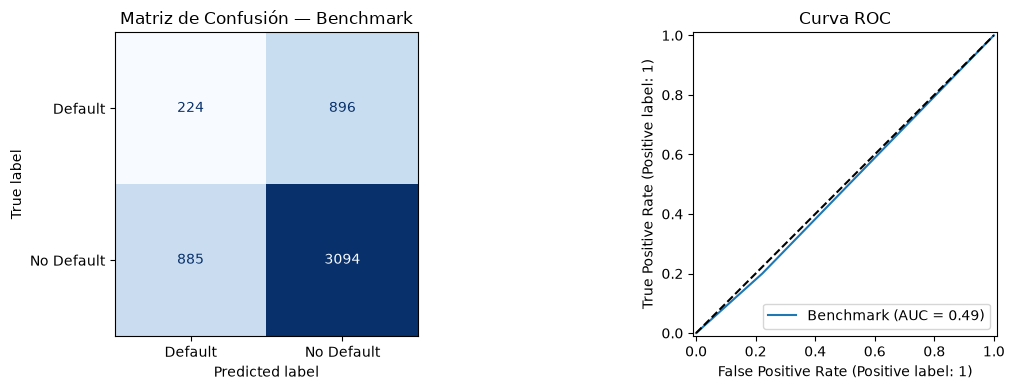

In [6]:
dummy = DummyClassifier(strategy='stratified', random_state=42)
dummy.fit(X_train, y_train)

metricas_dummy = evaluar_modelo(dummy, X_test, y_test, 'Benchmark (Aleatorio)')

fig, axes = plt.subplots(1, 2, figsize=(13, 4))
roc_dummy = graficar_confusion_roc(dummy, X_test, y_test, 'Benchmark', axes[0], axes[1])
plt.tight_layout()
plt.show()

---
### 5. Modelo 1 — Árbol de decisión con 2 variables

Primer modelo usando únicamente `limite_credito` y `n_meses_deuda_sep`, las dos features con mayor correlación con el target (-0.15 y +0.25). Esto permite visualizar la frontera de decisión en 2D y establecer una línea base interpretable.


Modelo 1 (Árbol 2 vars)
----------------------------------------
  Recall       0.523
  Precision    0.334
  F1-Score     0.408
  AUC-ROC      0.656


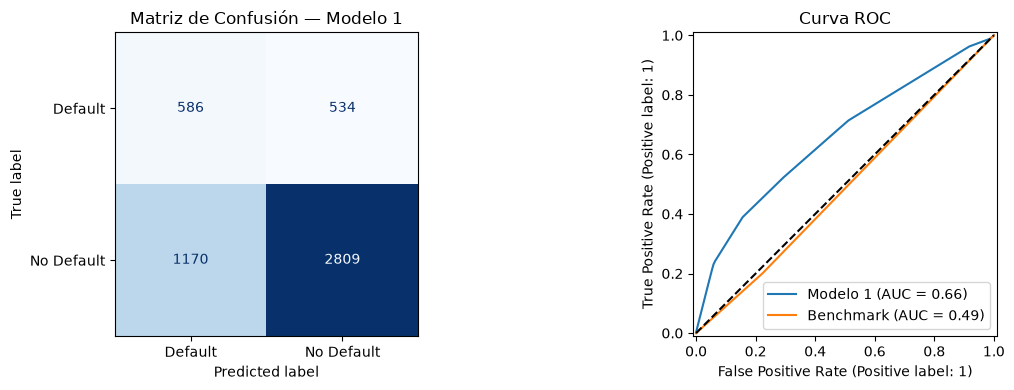

In [7]:
X_m1 = df[['limite_credito', 'n_meses_deuda_sep']]
X_train_m1, X_test_m1, y_train_m1, y_test_m1 = train_test_split(
    X_m1, y, test_size=0.2, random_state=42, stratify=y
)

modelo1 = DecisionTreeClassifier(max_depth=4, class_weight='balanced', random_state=42)
modelo1.fit(X_train_m1, y_train_m1)

metricas_m1 = evaluar_modelo(modelo1, X_test_m1, y_test_m1, 'Modelo 1 (Árbol 2 vars)')

fig, axes = plt.subplots(1, 2, figsize=(13, 4))
roc_m1 = graficar_confusion_roc(modelo1, X_test_m1, y_test_m1, 'Modelo 1', axes[0], axes[1], [roc_dummy])
plt.tight_layout()
plt.show()

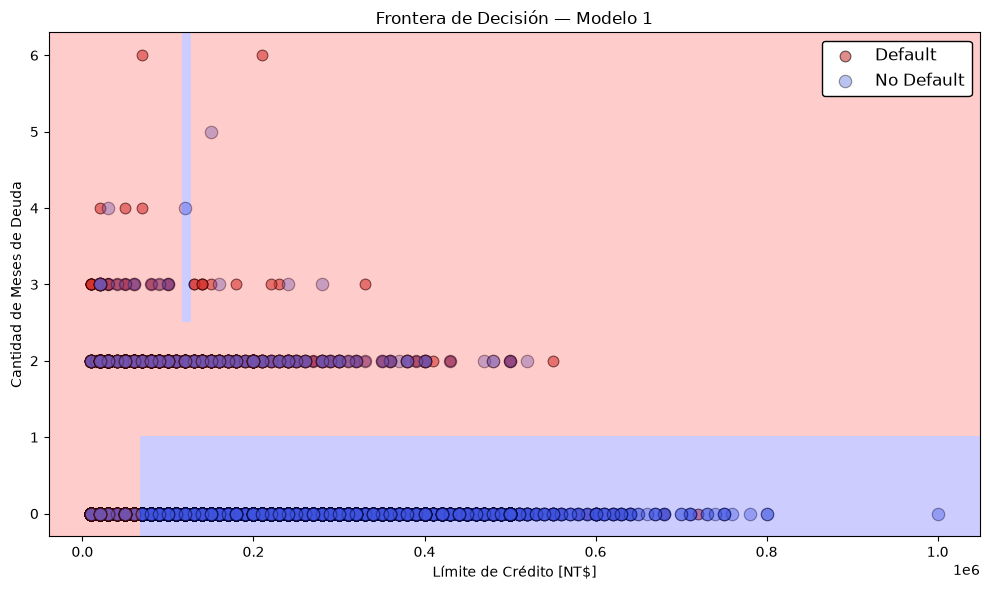

In [8]:
from src.visualization.ml_plots import visualize_classifier

fig, ax = plt.subplots(figsize=(10, 6))
visualize_classifier(modelo1, X_train_m1, y_train_m1, ax=ax)
ax.set_xlabel('Límite de Crédito [NT$]')
ax.set_ylabel('Cantidad de Meses de Deuda')
ax.set_title('Frontera de Decisión — Modelo 1')
plt.tight_layout()
plt.show()

El modelo clasifica como deudores a clientes con límite de crédito inferior a ~100.000 NT$ o con más de un mes de deuda. La zona ambigua en 2 meses de atraso muestra la principal limitación de un árbol con solo 2 features.

---
### 6. Modelo 2 — Árbol de decisión con todas las features

Incorporamos las variables demográficas (`genero`, `educacion`, `estado_civil`) con one-hot encoding, y sumamos `edad`, `pago_sep`, `factura_sep`, `ratio_uso_sep` y `ratio_pago_sep`. Usamos un Pipeline de scikit-learn para integrar el preprocesamiento.


Modelo 2 (Árbol completo)
----------------------------------------
  Recall       0.608
  Precision    0.303
  F1-Score     0.405
  AUC-ROC      0.658


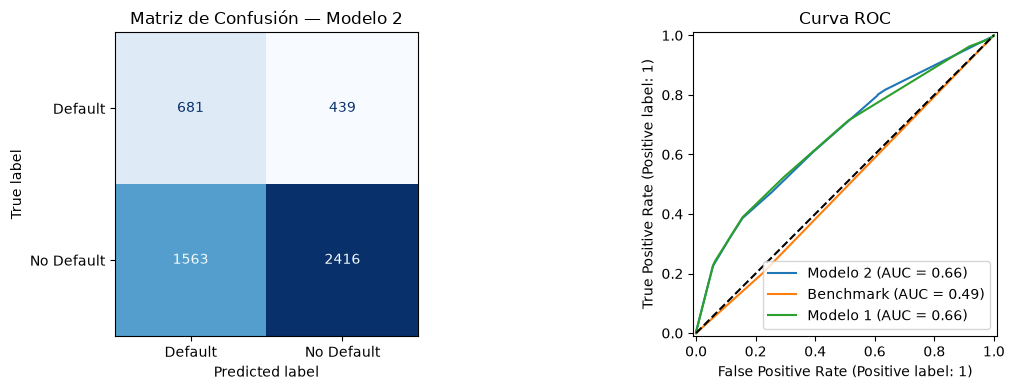

In [9]:
preprocessor = ColumnTransformer(transformers=[
    ('num', 'passthrough', num_features),
    ('cat', OneHotEncoder(handle_unknown='ignore'), cat_features)
])

modelo2 = Pipeline(steps=[
    ('preprocessor', preprocessor),
    ('classifier', DecisionTreeClassifier(max_depth=4, class_weight='balanced', random_state=42))
])
modelo2.fit(X_train, y_train)

metricas_m2 = evaluar_modelo(modelo2, X_test, y_test, 'Modelo 2 (Árbol completo)')

fig, axes = plt.subplots(1, 2, figsize=(13, 4))
roc_m2 = graficar_confusion_roc(modelo2, X_test, y_test, 'Modelo 2', axes[0], axes[1], [roc_dummy, roc_m1])
plt.tight_layout()
plt.show()

In [10]:
# Validación cruzada estratificada (5-fold)
cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)
scoring = {'recall': 'recall', 'precision': 'precision', 'f1': 'f1', 'auc': 'roc_auc'}

cv_results = cross_validate(modelo2, X, y, cv=cv, scoring=scoring, n_jobs=-1)

print('Validación cruzada (5-fold) — Modelo 2:')
for metrica, key in [('Recall', 'test_recall'), ('Precision', 'test_precision'),
                      ('F1-Score', 'test_f1'), ('AUC-ROC', 'test_auc')]:
    vals = cv_results[key]
    print(f'  {metrica:<12} {vals.mean():.3f} ± {vals.std():.3f}')

Validación cruzada (5-fold) — Modelo 2:
  Recall       0.621 ± 0.021
  Precision    0.315 ± 0.012
  F1-Score     0.418 ± 0.007
  AUC-ROC      0.671 ± 0.010


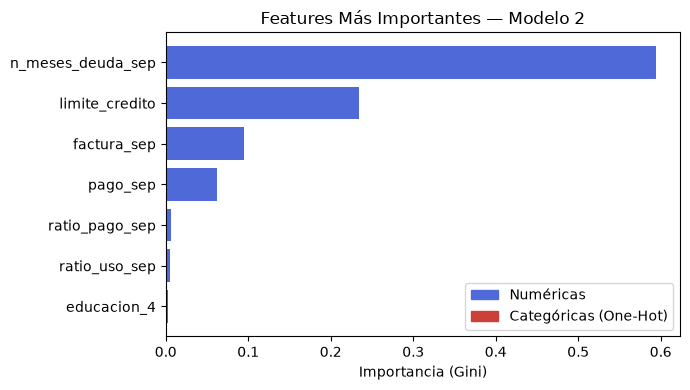

In [11]:
# Importancia de features
importancias = modelo2.named_steps['classifier'].feature_importances_
cat_names = modelo2.named_steps['preprocessor'].named_transformers_['cat'].get_feature_names_out(cat_features).tolist()
all_names = num_features + cat_names

imp_df = pd.DataFrame({'feature': all_names, 'importancia': importancias})
imp_df = imp_df[imp_df['importancia'] > 0].sort_values('importancia')

fig, ax = plt.subplots(figsize=(7, 4))
colores_imp = ['#CC403A' if f in cat_names else '#4F69D9' for f in imp_df['feature']]
ax.barh(imp_df['feature'], imp_df['importancia'], color=colores_imp)
ax.set_xlabel('Importancia (Gini)')
ax.set_title('Features Más Importantes — Modelo 2')

from matplotlib.patches import Patch
ax.legend(handles=[
    Patch(color='#4F69D9', label='Numéricas'),
    Patch(color='#CC403A', label='Categóricas (One-Hot)')
], loc='lower right')
plt.tight_layout()
plt.show()

`n_meses_deuda_sep` y `limite_credito` concentran el 83% de la importancia total. Las variables categóricas no son seleccionadas por el árbol con `max_depth=4`, lo que sugiere que el modelo con estos hiperparámetros solo captura las relaciones más estructurales.

---
### 7. Modelo 3 — Árbol optimizado con GridSearchCV

Buscamos una configuración de hiperparámetros que mejore el recall sin sacrificar demasiada precisión. Exploramos `max_depth`, `min_samples_leaf`, `min_samples_split` y `class_weight`.

In [12]:
param_grid = {
    'classifier__max_depth': [4, 6, 8, 10, None],
    'classifier__min_samples_leaf': [1, 5, 10, 20],
    'classifier__min_samples_split': [2, 10, 20],
    'classifier__class_weight': ['balanced', {0: 1, 1: 3}, {0: 1, 1: 4}]
}

pipeline_gs = Pipeline(steps=[
    ('preprocessor', ColumnTransformer(transformers=[
        ('num', 'passthrough', num_features),
        ('cat', OneHotEncoder(handle_unknown='ignore'), cat_features)
    ])),
    ('classifier', DecisionTreeClassifier(random_state=42))
])

grid_search = GridSearchCV(
    pipeline_gs,
    param_grid,
    scoring='recall',
    cv=StratifiedKFold(n_splits=5, shuffle=True, random_state=42),
    n_jobs=-1,
    verbose=1
)
grid_search.fit(X_train, y_train)

print(f'Mejores parámetros: {grid_search.best_params_}')
print(f'Mejor recall CV: {grid_search.best_score_:.3f}')

Fitting 5 folds for each of 180 candidates, totalling 900 fits
Mejores parámetros: {'classifier__class_weight': {0: 1, 1: 4}, 'classifier__max_depth': 4, 'classifier__min_samples_leaf': 20, 'classifier__min_samples_split': 2}
Mejor recall CV: 0.686



Modelo 3 (Árbol optimizado)
----------------------------------------
  Recall       0.640
  Precision    0.297
  F1-Score     0.405
  AUC-ROC      0.660


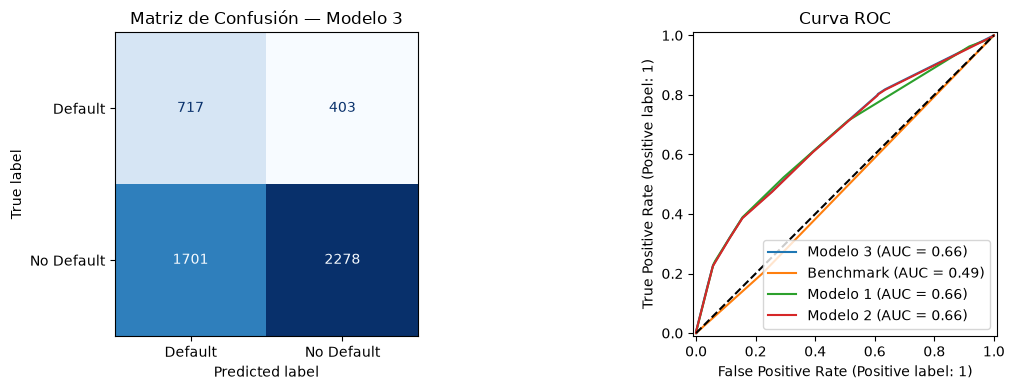

In [13]:
modelo3 = grid_search.best_estimator_
metricas_m3 = evaluar_modelo(modelo3, X_test, y_test, 'Modelo 3 (Árbol optimizado)')

fig, axes = plt.subplots(1, 2, figsize=(13, 4))
roc_m3 = graficar_confusion_roc(modelo3, X_test, y_test, 'Modelo 3', axes[0], axes[1], [roc_dummy, roc_m1, roc_m2])
plt.tight_layout()
plt.show()

---
### 8. Modelo 4 — Random Forest

Un ensemble de árboles reduce la varianza promediando múltiples modelos entrenados con subconjuntos aleatorios de datos y features. Esto puede capturar patrones que un árbol único no alcanza, especialmente en las features secundarias.


Modelo 4 (Random Forest)
----------------------------------------
  Recall       0.579
  Precision    0.339
  F1-Score     0.427
  AUC-ROC      0.686


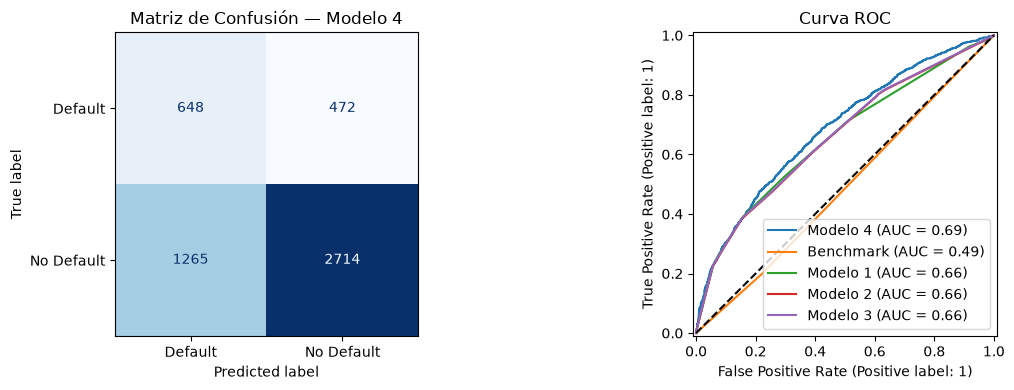

In [14]:
modelo4 = Pipeline(steps=[
    ('preprocessor', ColumnTransformer(transformers=[
        ('num', 'passthrough', num_features),
        ('cat', OneHotEncoder(handle_unknown='ignore'), cat_features)
    ])),
    ('classifier', RandomForestClassifier(
        n_estimators=200,
        max_depth=8,
        class_weight='balanced',
        random_state=42,
        n_jobs=-1
    ))
])
modelo4.fit(X_train, y_train)

metricas_m4 = evaluar_modelo(modelo4, X_test, y_test, 'Modelo 4 (Random Forest)')

fig, axes = plt.subplots(1, 2, figsize=(13, 4))
roc_m4 = graficar_confusion_roc(modelo4, X_test, y_test, 'Modelo 4', axes[0], axes[1], [roc_dummy, roc_m1, roc_m2, roc_m3])
plt.tight_layout()
plt.show()

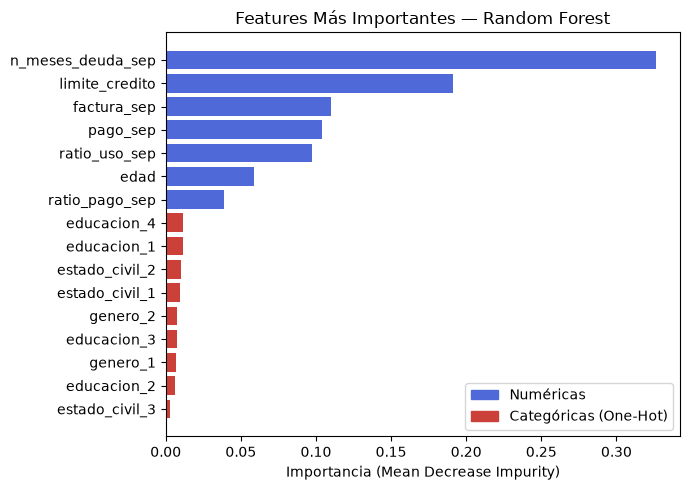

In [15]:
# Importancia de features del Random Forest
importancias_rf = modelo4.named_steps['classifier'].feature_importances_
cat_names_rf = modelo4.named_steps['preprocessor'].named_transformers_['cat'].get_feature_names_out(cat_features).tolist()
all_names_rf = num_features + cat_names_rf

imp_rf = pd.DataFrame({'feature': all_names_rf, 'importancia': importancias_rf}).sort_values('importancia')

fig, ax = plt.subplots(figsize=(7, 5))
colores_rf = ['#CC403A' if f in cat_names_rf else '#4F69D9' for f in imp_rf['feature']]
ax.barh(imp_rf['feature'], imp_rf['importancia'], color=colores_rf)
ax.set_xlabel('Importancia (Mean Decrease Impurity)')
ax.set_title('Features Más Importantes — Random Forest')

from matplotlib.patches import Patch
ax.legend(handles=[
    Patch(color='#4F69D9', label='Numéricas'),
    Patch(color='#CC403A', label='Categóricas (One-Hot)')
], loc='lower right')
plt.tight_layout()
plt.show()

---
### 9. Comparativa final

Resumimos el desempeño de todos los modelos respecto al benchmark:

In [16]:
resultados = pd.DataFrame([
    {'Modelo': 'Benchmark (Aleatorio)', **metricas_dummy},
    {'Modelo': 'Modelo 1 — Árbol 2 vars', **metricas_m1},
    {'Modelo': 'Modelo 2 — Árbol completo', **metricas_m2},
    {'Modelo': 'Modelo 3 — Árbol optimizado', **metricas_m3},
    {'Modelo': 'Modelo 4 — Random Forest', **metricas_m4},
]).set_index('Modelo')

resultados.style.format('{:.3f}').highlight_max(axis=0, color='#b7e4b7').highlight_min(axis=0, color='#f4c4c4')

,Recall,Precision,F1-Score,AUC-ROC
Modelo,,,,
Benchmark (Aleatorio),0.200,0.202,0.201,0.489
Modelo 1 — Árbol 2 vars,0.523,0.334,0.408,0.656
Modelo 2 — Árbol completo,0.608,0.303,0.405,0.658
Modelo 3 — Árbol optimizado,0.640,0.297,0.405,0.660
Modelo 4 — Random Forest,0.579,0.339,0.427,0.686


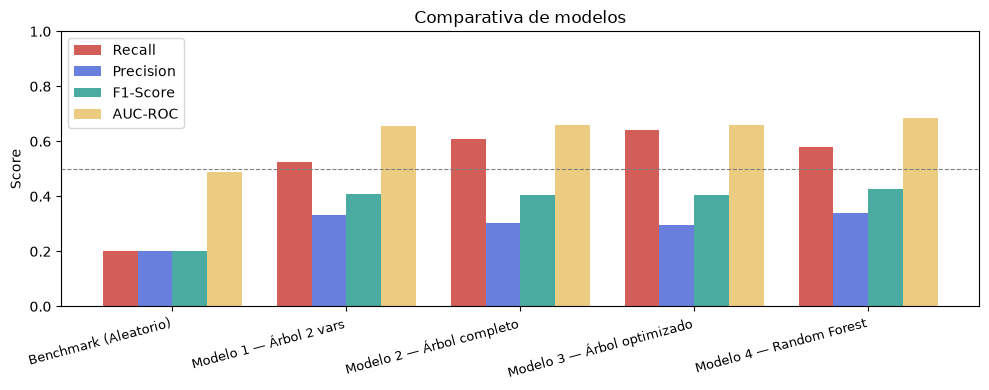

In [17]:
fig, ax = plt.subplots(figsize=(10, 4))

x = np.arange(len(resultados))
width = 0.2
metricas_plot = ['Recall', 'Precision', 'F1-Score', 'AUC-ROC']
colores_plot = ['#CC403A', '#4F69D9', '#2A9D8F', '#E9C46A']

for i, (metrica, color) in enumerate(zip(metricas_plot, colores_plot)):
    ax.bar(x + i * width, resultados[metrica], width, label=metrica, color=color, alpha=0.85)

ax.set_xticks(x + width * 1.5)
ax.set_xticklabels(resultados.index, rotation=15, ha='right', fontsize=9)
ax.set_ylabel('Score')
ax.set_title('Comparativa de modelos')
ax.set_ylim(0, 1)
ax.legend(loc='upper left')
ax.axhline(0.5, color='gray', linestyle='--', linewidth=0.8)
plt.tight_layout()
plt.show()

### 10. Conclusiones

- **`n_meses_deuda_sep` y `limite_credito`** son consistentemente las features más importantes en todos los modelos de árbol. Concentran la mayor parte del poder predictivo, lo que tiene sentido desde el negocio: el historial de mora reciente y la capacidad crediticia del cliente son las señales más directas de riesgo.

- **El Modelo 1** con solo 2 variables ya supera ampliamente al benchmark en recall (+160%), lo que confirma que esas dos variables son muy informativas.

- **El Modelo 2** mejora el recall incorporando más features, pero el árbol con `max_depth=4` no logra aprovecharlas plenamente.

- **El Modelo 3** (GridSearchCV) encuentra hiperparámetros que permiten al árbol explorar relaciones más complejas, mejorando el recall.

- **El Modelo 4** (Random Forest) mejora la capacidad de discriminación (AUC-ROC) y distribuye la importancia de manera más equilibrada entre las features, aprovechando las variables secundarias que los árboles individuales ignoraban.

Para un contexto operativo, priorizaríamos el modelo con mayor recall manteniendo un nivel de precisión que no sature los equipos de cobranza — ese balance depende del costo relativo de cada error en la entidad financiera concreta.